# Rating Curve BDWB Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

In [ ]:
"""
Sediment rating curve (Qs vs Q) per year.
Points connected in DATE ORDER (arrows) = hysteresis loop.
Points COLORED BY MONTH (1-12), colorbar shows month.
"""

# ---------- 1. LOAD DATA ----------
FILE = r'G:\Suspended Sediment of Ganges River Remote Sensing\Data_SSC_BWDB.xlsx'
df = pd.read_excel(FILE, sheet_name='Sheet2')

DATE = 'Date'
Q    = 'Discharge_m3/s'
QS   = 'SSC_Kg/s'

df[DATE] = pd.to_datetime(df[DATE], errors='coerce')
df = df.dropna(subset=[DATE, Q, QS]).sort_values(DATE).reset_index(drop=True)
df['year']  = df[DATE].dt.year
df['month'] = df[DATE].dt.month          # 1..12

OUTDIR = r'G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_rating_curves_BWDB_Qs_vs_Q'
os.makedirs(OUTDIR, exist_ok=True)

# fixed month color scale (1-12) so colors mean the same in EVERY plot
# discrete 12-color map -> each month clearly distinct, consistent across plots
base = plt.cm.turbo(np.linspace(0.05, 0.95, 12))   # 12 distinct colors
month_cmap = mcolors.ListedColormap(base)
month_norm = mcolors.BoundaryNorm(np.arange(0.5, 13.5, 1), month_cmap.N)

# ---------- 2. ONE PLOT PER YEAR ----------
for yr, g in df.groupby('year'):
    g = g.sort_values(DATE).reset_index(drop=True)
    if len(g) < 3:
        continue

    x = g[Q].values.astype(float)
    y = g[QS].values.astype(float)
    m = g['month'].values                  # month of each point

    fig, ax = plt.subplots(figsize=(8, 6))

    # arrows connecting points in date order
    for i in range(len(g) - 1):
        ax.annotate('', xy=(x[i+1], y[i+1]), xytext=(x[i], y[i]),
                    arrowprops=dict(arrowstyle='->', color='gray',
                                    lw=1.2, alpha=0.8))

    # points colored by MONTH (fixed 1-12 scale)
    sc = ax.scatter(x, y, c=m, cmap=month_cmap, norm=month_norm,
                    s=70, edgecolor='k', linewidth=0.4, zorder=3)

    # label first and last date
    ax.annotate(g[DATE].iloc[0].strftime('%b %d'), (x[0], y[0]),
                textcoords='offset points', xytext=(6, 6), fontsize=8, color='black')
    ax.annotate(g[DATE].iloc[-1].strftime('%b %d'), (x[-1], y[-1]),
                textcoords='offset points', xytext=(6, 6), fontsize=8, color='black')

    ax.set_xlabel('Water discharge  Q  (m³/s)')
    ax.set_ylabel('Sediment discharge  Qs  (kg/s)')
    ax.set_title(f'Sediment rating curve — {yr}  (color = month)')
    ax.grid(True, alpha=0.3)

    # colorbar showing months 1-12 with month names
    cbar = fig.colorbar(sc, ax=ax, ticks=range(1, 13))
    cbar.set_label('Month')
    cbar.ax.set_yticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                             'Jul','Aug','Sep','Oct','Nov','Dec'])

    fig.tight_layout()
    out = os.path.join(OUTDIR, f'rating_curve_Qs_vs_Q_{yr}.png')
    fig.savefig(out, dpi=150)
    plt.close(fig)
    print('saved', out)

print('\nDone. Plots in', OUTDIR)

saved G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_rating_curves_BWDB_Qs_vs_Q\rating_curve_Qs_vs_Q_1966.png
saved G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_rating_curves_BWDB_Qs_vs_Q\rating_curve_Qs_vs_Q_1967.png
saved G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_rating_curves_BWDB_Qs_vs_Q\rating_curve_Qs_vs_Q_1968.png
saved G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_rating_curves_BWDB_Qs_vs_Q\rating_curve_Qs_vs_Q_1969.png
saved G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_rating_curves_BWDB_Qs_vs_Q\rating_curve_Qs_vs_Q_1970.png
saved G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_rating_curves_BWDB_Qs_vs_Q\rating_curve_Qs_vs_Q_1976.png
saved G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_rating_curves_BWDB_Qs_vs_Q\rating_curve_Qs_vs_Q_1978.png
saved G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_rating_curves_BWDB_Qs_vs_Q\rating_curve_Qs_vs_Q_1979.png
saved G:\Suspend

# Single Plot

In [ ]:
"""
All years in ONE figure — grid of sediment rating curves (Qs vs Q).
6 columns, rows auto-calculated. Points connected in date order (arrows).
Points COLORED BY MONTH (same colors in every panel) + one shared month colorbar.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import math

# ---------- 1. LOAD DATA ----------
FILE = r'G:\Suspended Sediment of Ganges River Remote Sensing\Data_SSC_BWDB.xlsx'
df = pd.read_excel(FILE, sheet_name='Sheet2')

DATE = 'Date'
Q    = 'Discharge_m3/s'
QS   = 'SSC_Kg/s'

df[DATE] = pd.to_datetime(df[DATE], errors='coerce')
df = df.dropna(subset=[DATE, Q, QS]).sort_values(DATE).reset_index(drop=True)
df['year']  = df[DATE].dt.year
df['month'] = df[DATE].dt.month

years = sorted(df['year'].unique())

# ---- fixed month colormap (same in every panel) ----
base = plt.cm.turbo(np.linspace(0.05, 0.95, 12))
month_cmap = mcolors.ListedColormap(base)
month_norm = mcolors.BoundaryNorm(np.arange(0.5, 13.5, 1), month_cmap.N)

# ---------- 2. GRID LAYOUT ----------
NCOL = 6
NROW = math.ceil(len(years) / NCOL)
print(f'{len(years)} years -> {NROW} rows x {NCOL} cols')

fig, axes = plt.subplots(NROW, NCOL, figsize=(NCOL*4, NROW*4))
axes = np.array(axes).reshape(-1)

sc = None
for ax, yr in zip(axes, years):
    g = df[df['year'] == yr].sort_values(DATE).reset_index(drop=True)
    if len(g) < 2:
        ax.set_visible(False); continue
    x = g[Q].values.astype(float)
    y = g[QS].values.astype(float)
    m = g['month'].values

    # arrows in date order
    for i in range(len(g) - 1):
        ax.annotate('', xy=(x[i+1], y[i+1]), xytext=(x[i], y[i]),
                    arrowprops=dict(arrowstyle='->', color='black',
                                    lw=0.8, alpha=0.7))
    # points colored by MONTH (fixed scale -> same across panels)
    sc = ax.scatter(x, y, c=m, cmap=month_cmap, norm=month_norm,
                    s=30, edgecolor='k', linewidth=0.3, zorder=3)

    # first & last date labels
    ax.annotate(g[DATE].iloc[0].strftime('%b %d'), (x[0], y[0]),
                textcoords='offset points', xytext=(5, 5),
                fontsize=7, color='black', fontweight='bold')
    ax.annotate(g[DATE].iloc[-1].strftime('%b %d'), (x[-1], y[-1]),
                textcoords='offset points', xytext=(5, -8),
                fontsize=7, color='black', fontweight='bold')

    ax.set_title(str(yr), fontsize=10)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

# hide unused panels
for ax in axes[len(years):]:
    ax.set_visible(False)

fig.supxlabel('Water discharge  Q  (m³/s)', fontsize=12)
fig.supylabel('Sediment discharge  Qs  (kg/s)', fontsize=12)
fig.suptitle('Sediment rating curves by year (color = month)', fontsize=14, y=1.01)

# ---- one shared month colorbar for the whole figure ----
fig.tight_layout(rect=[0, 0, 0.94, 1])   # leave room on right for colorbar
cax = fig.add_axes([0.955, 0.15, 0.012, 0.7])
cbar = fig.colorbar(sc, cax=cax, ticks=range(1, 13))
cbar.set_label('Month')
cbar.ax.set_yticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec'])

out = r'G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_rating_curves_BWDB_Qs_vs_Q\rating_curves_grid_Qs_vs_Q_1966_2020.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('saved', out)

# Yearly Qs and Q Hydrograph


In [2]:
"""
Per-year time series: Q (discharge) and Qs (sediment discharge) vs date.
Q on LEFT axis, Qs on RIGHT (secondary) axis. One plot per year.
Run in VS Code.  Requires: pandas, matplotlib, openpyxl
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# ---------- 1. LOAD DATA ----------
FILE = r'G:\Suspended Sediment of Ganges River Remote Sensing\Data_SSC_BWDB.xlsx'
df = pd.read_excel(FILE, sheet_name='Sheet2')

DATE = 'Date'
Q    = 'Discharge_m3/s'      # water discharge (left axis)
QS   = 'SSC_Kg/s'            # sediment discharge (right axis)

df[DATE] = pd.to_datetime(df[DATE], errors='coerce')
df = df.dropna(subset=[DATE, Q, QS]).sort_values(DATE).reset_index(drop=True)
df['year'] = df[DATE].dt.year

OUTDIR = r'G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_Q_Qs_timeseries'
os.makedirs(OUTDIR, exist_ok=True)

# ---------- 2. ONE PLOT PER YEAR ----------
for yr, g in df.groupby('year'):
    g = g.sort_values(DATE).reset_index(drop=True)
    if len(g) < 2:
        continue

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # LEFT axis: Q (discharge)
    c1 = 'tab:blue'
    l1, = ax1.plot(g[DATE], g[Q], color=c1, marker='o', ms=4,
                   lw=1.5, label='Q (discharge)')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Water discharge  Q  (m³/s)', color=c1)
    ax1.tick_params(axis='y', labelcolor=c1)
    ax1.grid(True, alpha=0.3)

    # RIGHT axis: Qs (sediment discharge)
    ax2 = ax1.twinx()
    c2 = 'tab:red'
    l2, = ax2.plot(g[DATE], g[QS], color=c2, marker='s', ms=4,
                   lw=1.5, label='Qs (sediment)')
    ax2.set_ylabel('Sediment discharge  Qs  (kg/s)', color=c2)
    ax2.tick_params(axis='y', labelcolor=c2)

    # ---- MARK THE PEAKS (dots only, no floating callout boxes) ----
    iq = g[Q].idxmax()
    q_date, q_val = g.loc[iq, DATE], g.loc[iq, Q]
    ax1.scatter([q_date], [q_val], color=c1, s=90, zorder=5,
                edgecolor='k', linewidth=0.6)

    iqs = g[QS].idxmax()
    qs_date, qs_val = g.loc[iqs, DATE], g.loc[iqs, QS]
    ax2.scatter([qs_date], [qs_val], color=c2, s=90, zorder=5,
                edgecolor='k', linewidth=0.6)

    # add headroom so peaks aren't jammed at the top
    ax1.margins(y=0.15)
    ax2.margins(y=0.15)

    # x-axis as months
    ax1.xaxis.set_major_locator(mdates.MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    # combined legend
    leg = ax1.legend(handles=[l1, l2], loc='upper left')

    ax1.set_title(f'Discharge (Q) & Sediment (Qs) — {yr}')

    # ---- info box below legend: peak dates + lag ----
    lag_days = (q_date - qs_date).days
    lag_txt = (f'Qs leads Q by {abs(lag_days)} d' if lag_days > 0
               else f'Q leads Qs by {abs(lag_days)} d' if lag_days < 0
               else 'Q & Qs peak same day')

    info_txt = (f"Q peak: {q_date.strftime('%b %d')}\n"
                f"Qs peak: {qs_date.strftime('%b %d')}\n"
                f"{lag_txt}")

    fig.canvas.draw()  # forces legend layout so we can get its real bbox
    bbox = leg.get_window_extent()
    inv = ax1.transAxes.inverted()
    bbox_axes = inv.transform(bbox)  # [[x0,y0],[x1,y1]] in axes coords

    ax1.text(bbox_axes[0][0], bbox_axes[0][1] - 0.03, info_txt,
              transform=ax1.transAxes, ha='left', va='top', fontsize=9,
              fontweight='bold', color='black',
              bbox=dict(boxstyle='round,pad=0.3', fc='white',
                         ec='gray', alpha=0.9))

    fig.tight_layout()
    out = os.path.join(OUTDIR, f'Q_Qs_timeseries_{yr}.png')
    fig.savefig(out, dpi=150)
    plt.close(fig)
    print('saved', out)

print('\nDone. Plots in', OUTDIR)

saved G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_Q_Qs_timeseries\Q_Qs_timeseries_1966.png
saved G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_Q_Qs_timeseries\Q_Qs_timeseries_1967.png
saved G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_Q_Qs_timeseries\Q_Qs_timeseries_1968.png
saved G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_Q_Qs_timeseries\Q_Qs_timeseries_1969.png
saved G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_Q_Qs_timeseries\Q_Qs_timeseries_1970.png
saved G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_Q_Qs_timeseries\Q_Qs_timeseries_1976.png
saved G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_Q_Qs_timeseries\Q_Qs_timeseries_1978.png
saved G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_Q_Qs_timeseries\Q_Qs_timeseries_1979.png
saved G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_Q_Qs_timeseries\Q_Qs_timeseries_1980.png
saved G:\Suspended Sediment of Ganges

# Rating Curve of Qs Q

Monsoon points: 289, Dry points: 160
Monsoon:  Qs = 0.00058 * Q^1.6165   (R² = 0.507)
Dry:      Qs = 0.0000004304 * Q^2.3185   (R² = 0.624)


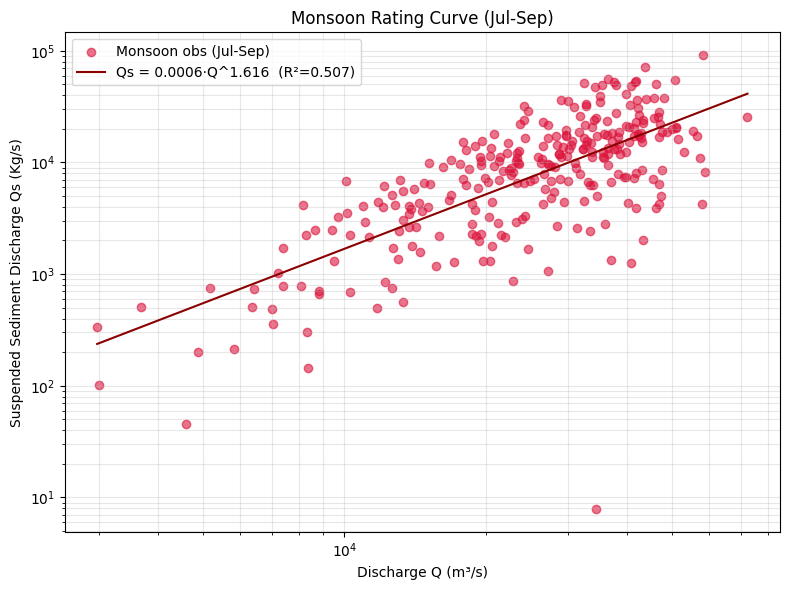

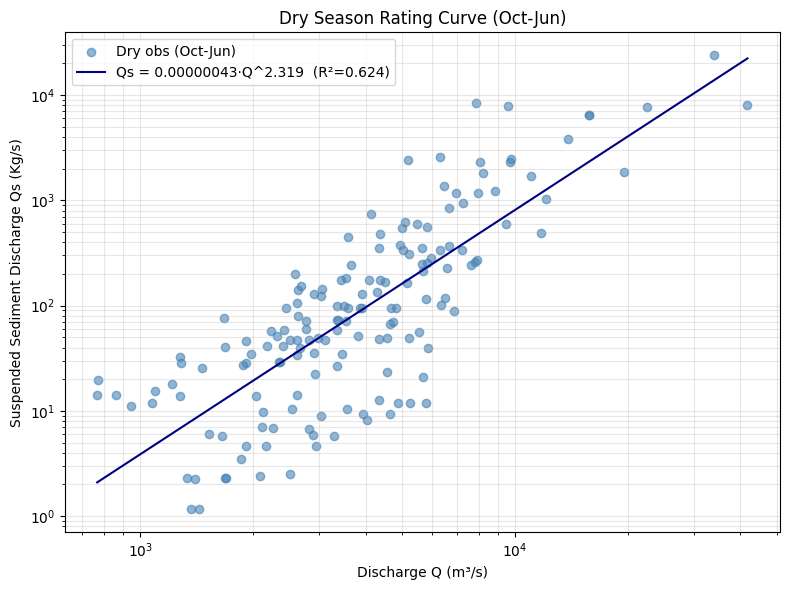

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

# ---------- 1. LOAD DATA ----------
FILE = r'G:\Suspended Sediment of Ganges River Remote Sensing\Data_SSC_BWDB.xlsx'
df = pd.read_excel(FILE, sheet_name='Sheet2')

DATE = 'Date'
Q    = 'Discharge_m3/s'
QS   = 'SSC_Kg/s'

df[DATE] = pd.to_datetime(df[DATE], errors='coerce')
df = df.dropna(subset=[DATE, Q, QS]).sort_values(DATE).reset_index(drop=True)
df['year']  = df[DATE].dt.year
df['month'] = df[DATE].dt.month          # 1..12

OUTDIR = r'G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_rating_curves_BWDB_Qs_vs_Q'
os.makedirs(OUTDIR, exist_ok=True)
# df.head(20)

# ---------- 2. SPLIT INTO SEASONS ----------
MONSOON_MONTHS = [7, 8, 9]
DRY_MONTHS     = [11, 12, 1, 2, 3]

df_monsoon = df[df['month'].isin(MONSOON_MONTHS)].copy()
df_dry     = df[df['month'].isin(DRY_MONTHS)].copy()

print(f"Monsoon points: {len(df_monsoon)}, Dry points: {len(df_dry)}")

# ---------- 3. FIT Qs = a * Q^b  (log-log linear regression) ----------
def fit_rating_curve(data, q_col, qs_col):
    """Fit Qs = a * Q^b via log-log OLS. Returns a, b, r_squared."""
    d = data[(data[q_col] > 0) & (data[qs_col] > 0)]
    log_q  = np.log(d[q_col])
    log_qs = np.log(d[qs_col])

    b, log_a = np.polyfit(log_q, log_qs, 1)
    a = np.exp(log_a)

    # R^2 in log space
    pred = log_a + b * log_q
    ss_res = np.sum((log_qs - pred)**2)
    ss_tot = np.sum((log_qs - log_qs.mean())**2)
    r2 = 1 - ss_res/ss_tot

    return a, b, r2

a_monsoon, b_monsoon, r2_monsoon = fit_rating_curve(df_monsoon, Q, QS)
a_dry,     b_dry,     r2_dry     = fit_rating_curve(df_dry, Q, QS)

print(f"Monsoon:  Qs = {a_monsoon:.5f} * Q^{b_monsoon:.4f}   (R² = {r2_monsoon:.3f})")
print(f"Dry:      Qs = {a_dry:.10f} * Q^{b_dry:.4f}   (R² = {r2_dry:.3f})")

# ---------- 4. PLOT MONSOON CURVE (separate figure) ----------
fig, ax = plt.subplots(figsize=(8, 6))

q_range_m = np.linspace(df_monsoon[Q].min(), df_monsoon[Q].max(), 100)

ax.scatter(df_monsoon[Q], df_monsoon[QS], color='crimson', alpha=0.6, label='Monsoon obs (Jul-Sep)')
ax.plot(q_range_m, a_monsoon * q_range_m**b_monsoon, color='darkred',
        label=f'Qs = {a_monsoon:.4f}·Q^{b_monsoon:.3f}  (R²={r2_monsoon:.3f})')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Discharge Q (m³/s)')
ax.set_ylabel('Suspended Sediment Discharge Qs (Kg/s)')
ax.set_title('Monsoon Rating Curve (Jul-Sep)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'monsoon_rating_curve.png'), dpi=150)
plt.show()

# ---------- 4b. PLOT DRY SEASON CURVE (separate figure) ----------
fig, ax = plt.subplots(figsize=(8, 6))

q_range_d = np.linspace(df_dry[Q].min(), df_dry[Q].max(), 100)

ax.scatter(df_dry[Q], df_dry[QS], color='steelblue', alpha=0.6, label='Dry obs (Oct-Jun)')
ax.plot(q_range_d, a_dry * q_range_d**b_dry, color='navy',
        label=f'Qs = {a_dry:.8f}·Q^{b_dry:.3f}  (R²={r2_dry:.3f})')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Discharge Q (m³/s)')
ax.set_ylabel('Suspended Sediment Discharge Qs (Kg/s)')
ax.set_title('Dry Season Rating Curve (Oct-Jun)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'dry_rating_curve.png'), dpi=150)
plt.show()

In [5]:
# ---------- 5. LOAD Q TIME SERIES & RESAMPLE TO DAILY ----------
FILE_Q = r'G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_rating_curves_BWDB_Qs_vs_Q\YearlyQ.xlsx'
df_q = pd.read_excel(FILE_Q, sheet_name='Sheet1')

df_q['Date'] = pd.to_datetime(df_q['Date'], errors='coerce')
df_q = df_q.dropna(subset=['Date', 'Q']).sort_values('Date').reset_index(drop=True)

df_daily = (df_q.set_index('Date')['Q']
                 .resample('D').mean()
                 .dropna()
                 .reset_index())
df_daily.columns = ['Date', 'Q']

df_daily['year']  = df_daily['Date'].dt.year
df_daily['month'] = df_daily['Date'].dt.month

def get_season(month):
    return 'Monsoon' if month in [7, 8, 9] else 'Dry'

df_daily['season'] = df_daily['month'].apply(get_season)

# ---------- 6. APPLY SEASONAL RATING CURVES ----------
def compute_qs(row):
    if row['season'] == 'Monsoon':
        return a_monsoon * row['Q'] ** b_monsoon
    else:
        return a_dry * row['Q'] ** b_dry

df_daily['Qs'] = df_daily.apply(compute_qs, axis=1)

df_monsoon_ts = df_daily[df_daily['season'] == 'Monsoon'][['Date', 'Q', 'Qs']].reset_index(drop=True)
df_dry_ts     = df_daily[df_daily['season'] == 'Dry'][['Date', 'Q', 'Qs']].reset_index(drop=True)

print(f"Monsoon daily records: {len(df_monsoon_ts)}")
print(f"Dry daily records: {len(df_dry_ts)}")

# ---------- 7. SAVE CSVs ----------
df_daily.to_csv(os.path.join(OUTDIR, 'daily_Q_Qs_full_2017_2020.csv'), index=False)
df_monsoon_ts.to_csv(os.path.join(OUTDIR, 'daily_Qs_monsoon.csv'), index=False)
df_dry_ts.to_csv(os.path.join(OUTDIR, 'daily_Qs_dry.csv'), index=False)
print("CSV files saved to:", OUTDIR)

Monsoon daily records: 368
Dry daily records: 755
CSV files saved to: G:\Suspended Sediment of Ganges River Remote Sensing\Yearly_rating_curves_BWDB_Qs_vs_Q


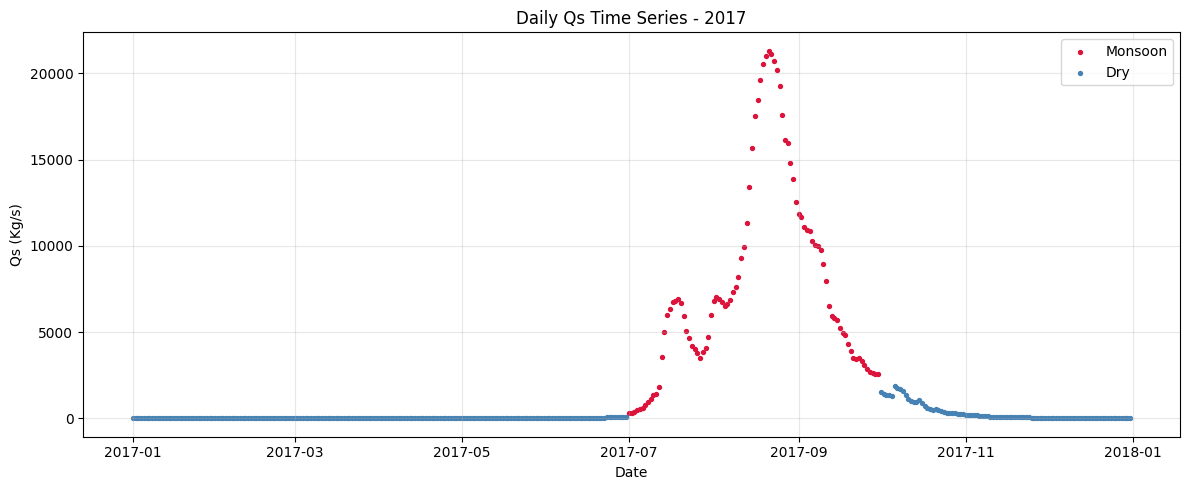

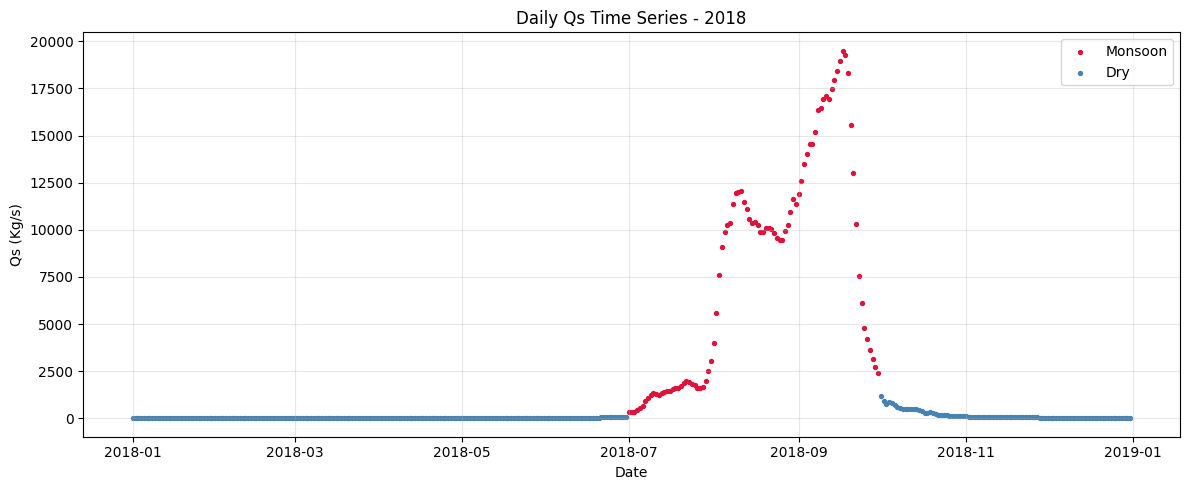

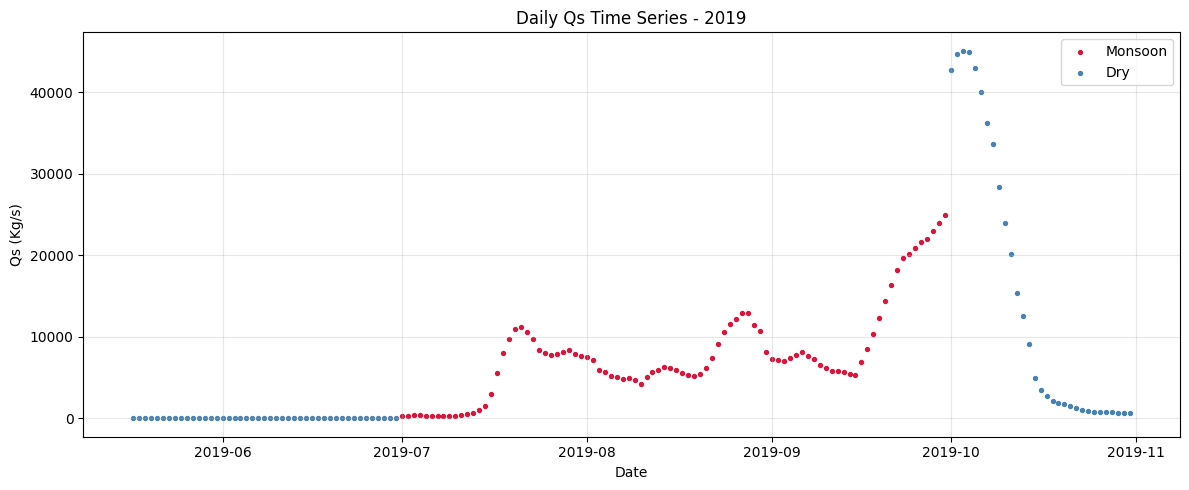

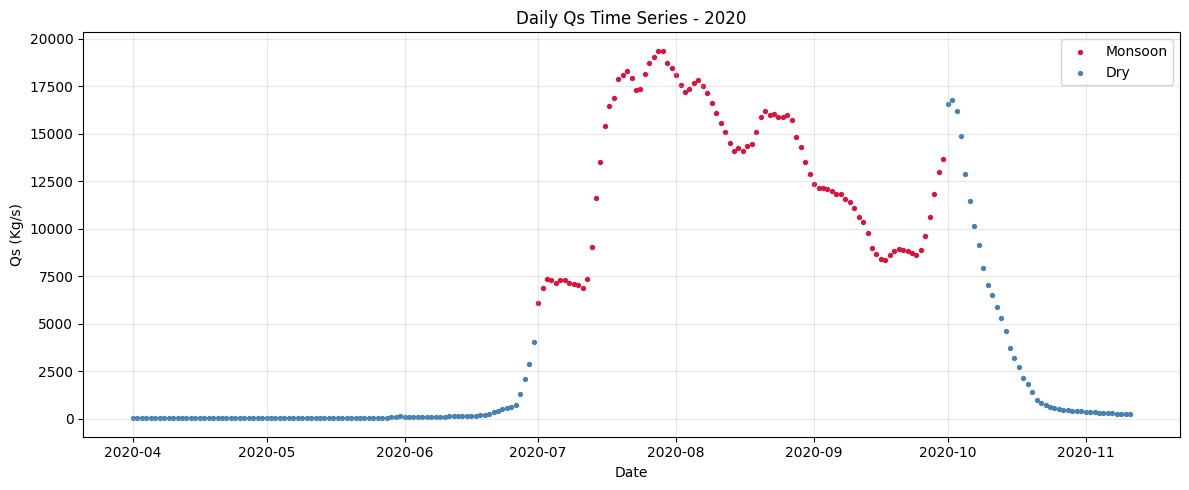

In [6]:
# ---------- 8. SEPARATE YEARLY PLOTS (2017-2020) ----------
years = [2017, 2018, 2019, 2020]
season_colors = {'Monsoon': 'crimson', 'Dry': 'steelblue'}

for yr in years:
    d = df_daily[df_daily['year'] == yr]
    if d.empty:
        continue
    fig, ax = plt.subplots(figsize=(12, 5))
    for season, color in season_colors.items():
        sub = d[d['season'] == season]
        ax.scatter(sub['Date'], sub['Qs'], s=8, color=color, label=season)
    ax.set_title(f'Daily Qs Time Series - {yr}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Qs (Kg/s)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f'Qs_timeseries_{yr}.png'), dpi=150)
    plt.show()

# Qs time series per year MT/yr
kg/s  =  (86400 x 365)/ (1000*1000000) MT/year 

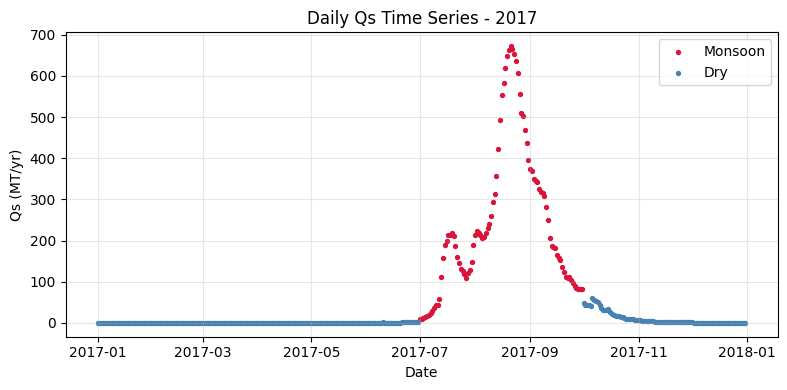

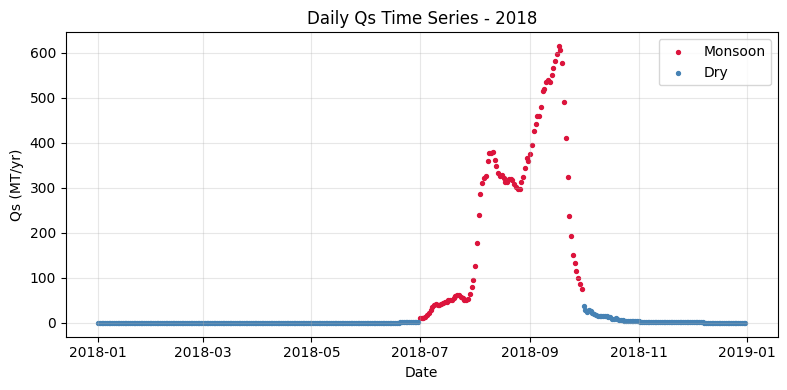

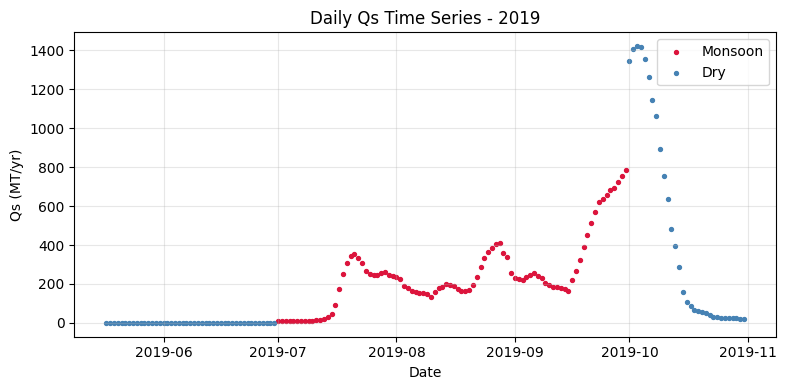

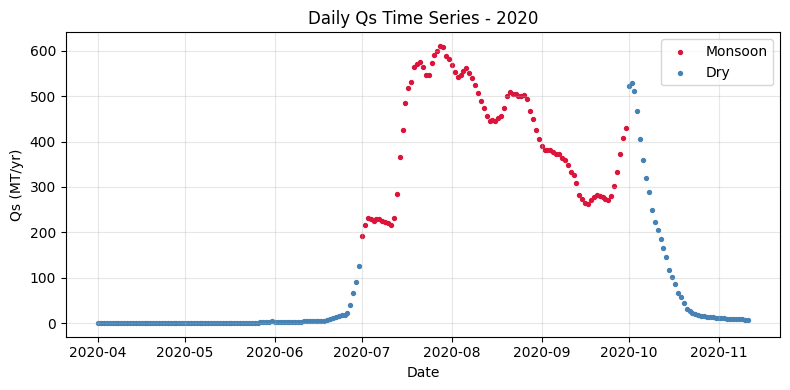

In [11]:
# ---------- 8. SEPARATE YEARLY PLOTS (2017-2020) ----------
years = [2017, 2018, 2019, 2020]
season_colors = {'Monsoon': 'crimson', 'Dry': 'steelblue'}

for yr in years:
    d = df_daily[df_daily['year'] == yr]
    if d.empty:
        continue
    fig, ax = plt.subplots(figsize=(8, 4))
    for season, color in season_colors.items():
        sub = d[d['season'] == season]
        ax.scatter(sub['Date'], sub['Qs']*(86400*365)/(1000*10**6), s=8, color=color, label=season)
    ax.set_title(f'Daily Qs Time Series - {yr}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Qs (MT/yr)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f'Qs(MT_yr)_timeseries_{yr}.png'), dpi=150)
    plt.show()

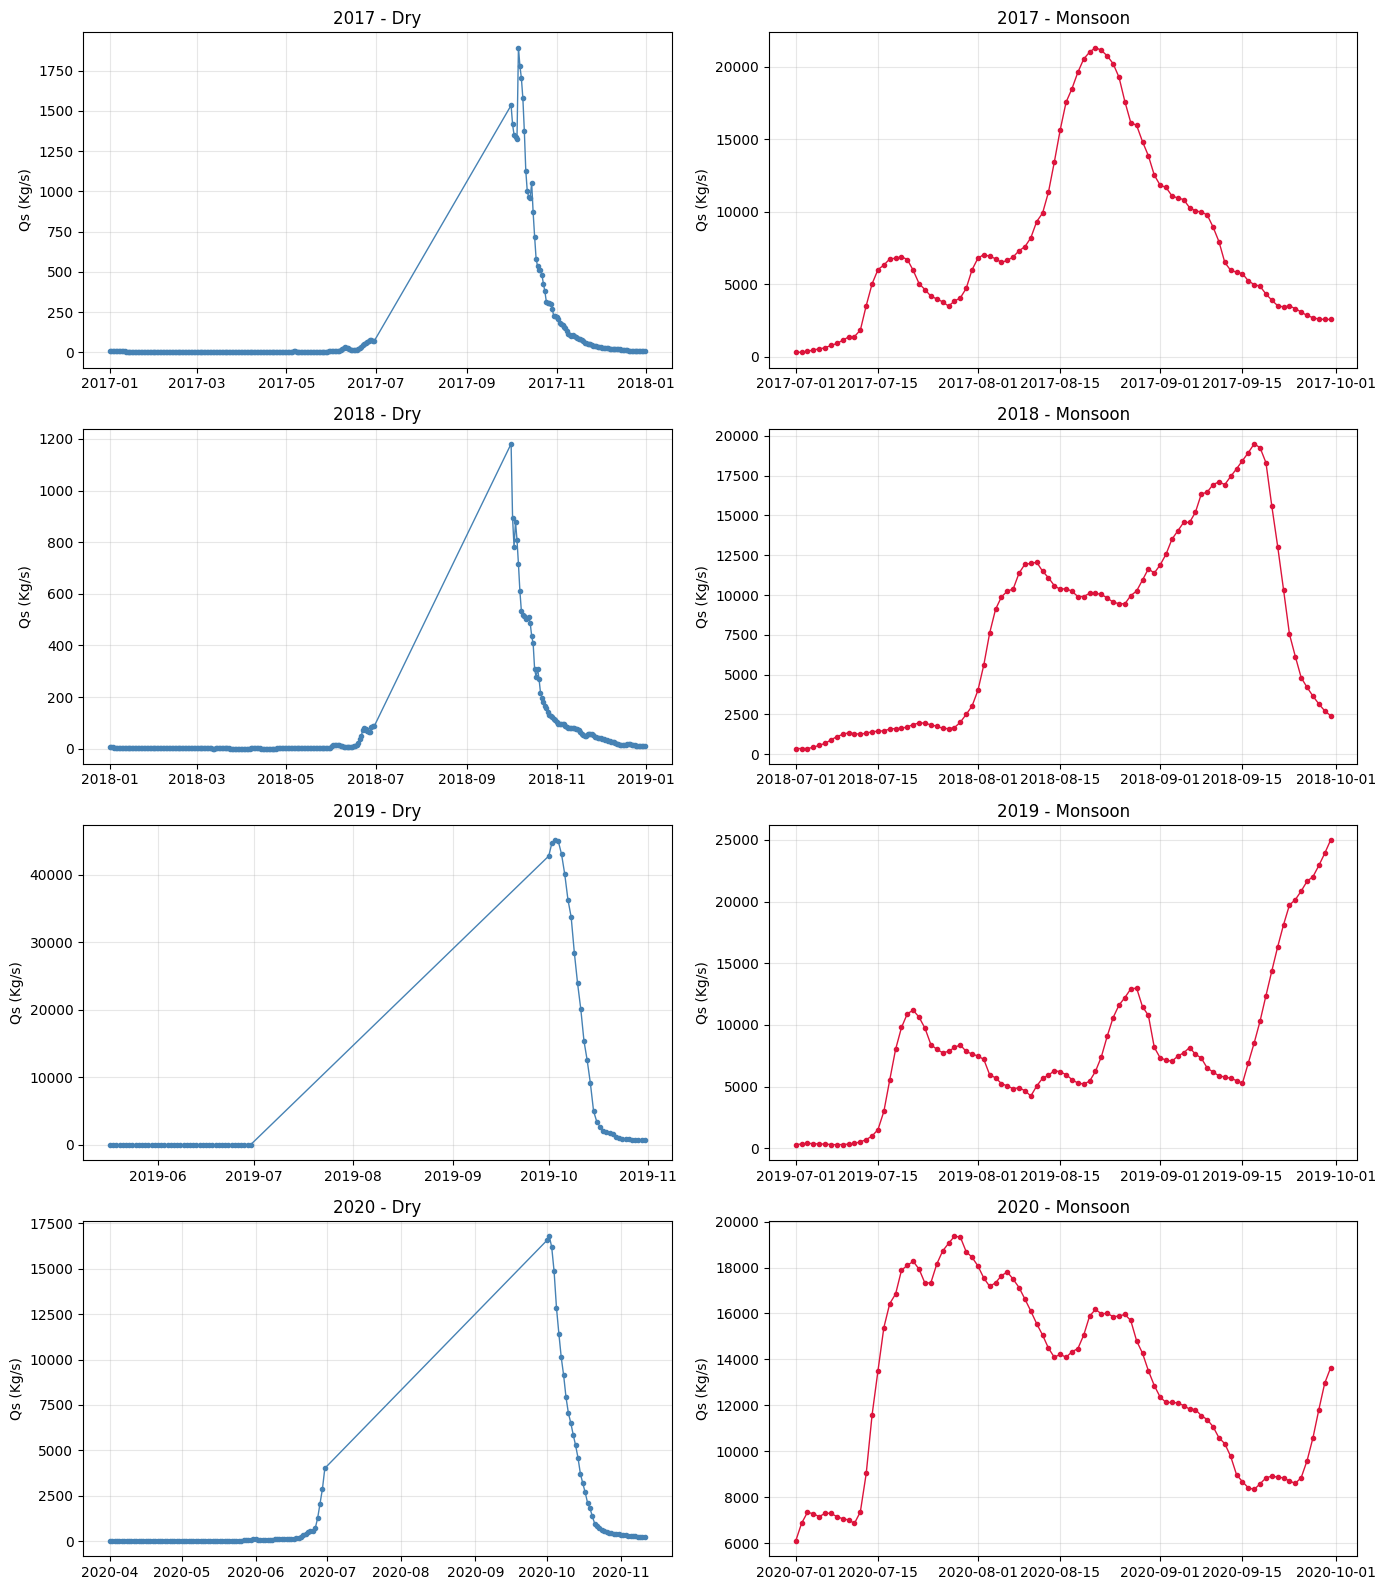

In [15]:
# ---------- 9. 8-PANEL GRID: 4 YEARS (rows) x 2 SEASONS (cols) ----------
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for i, yr in enumerate(years):
    for j, season in enumerate(['Dry', 'Monsoon']):
        ax = axes[i, j]
        d = df_daily[(df_daily['year'] == yr) & (df_daily['season'] == season)]
        ax.plot(d['Date'], d['Qs'], color=season_colors[season],
                marker='o', markersize=3, linewidth=1)
        ax.set_title(f'{yr} - {season}')
        ax.set_ylabel('Qs (Kg/s)')
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'grid_8panel_year_season.png'), dpi=150)
plt.show()

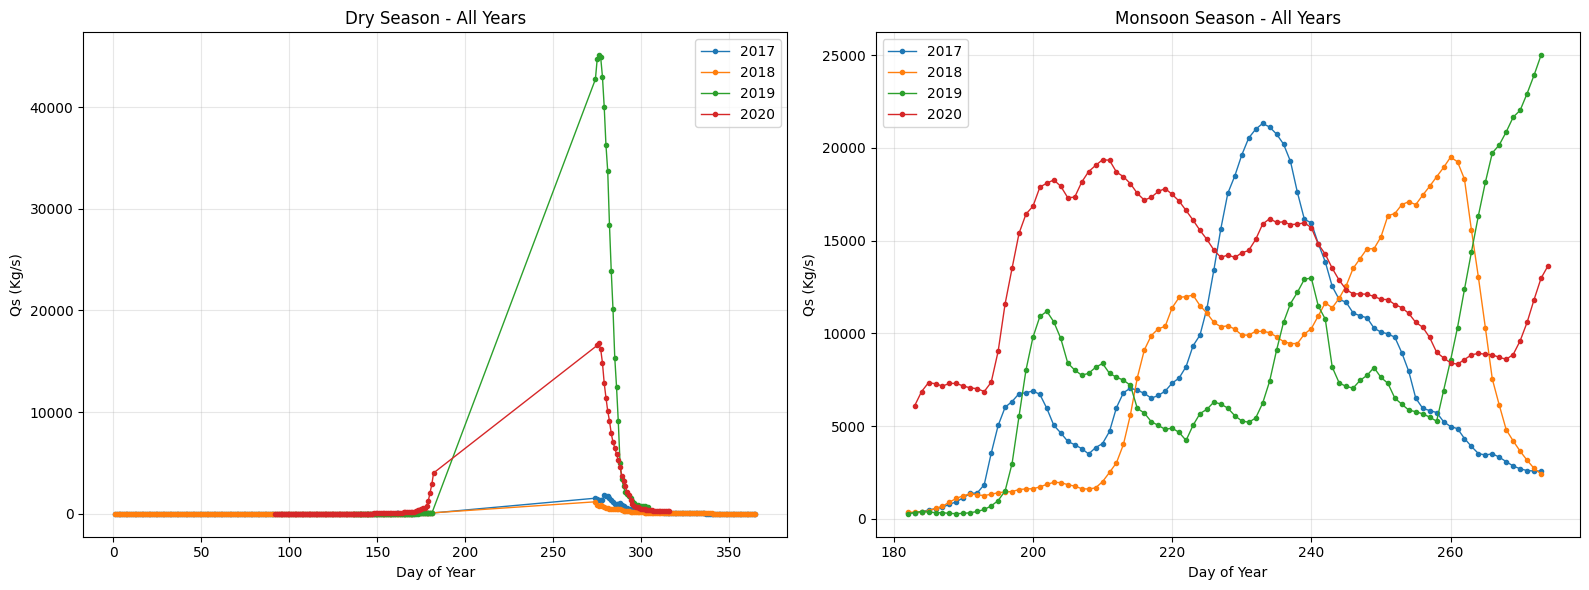

In [16]:
# ---------- 10. TWO-PANEL PLOT: DRY | MONSOON, ALL YEARS OVERLAID ----------
year_colors = {2017: 'tab:blue', 2018: 'tab:orange', 2019: 'tab:green', 2020: 'tab:red'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for season, ax in zip(['Dry', 'Monsoon'], axes):
    for yr in years:
        d = df_daily[(df_daily['year'] == yr) & (df_daily['season'] == season)].copy()
        if d.empty:
            continue
        d['doy'] = d['Date'].dt.dayofyear
        ax.plot(d['doy'], d['Qs'], color=year_colors[yr], marker='o',
                markersize=3, linewidth=1, label=str(yr))
    ax.set_title(f'{season} Season - All Years')
    ax.set_xlabel('Day of Year')
    ax.set_ylabel('Qs (Kg/s)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'dry_monsoon_allyears_combined.png'), dpi=150)
plt.show()

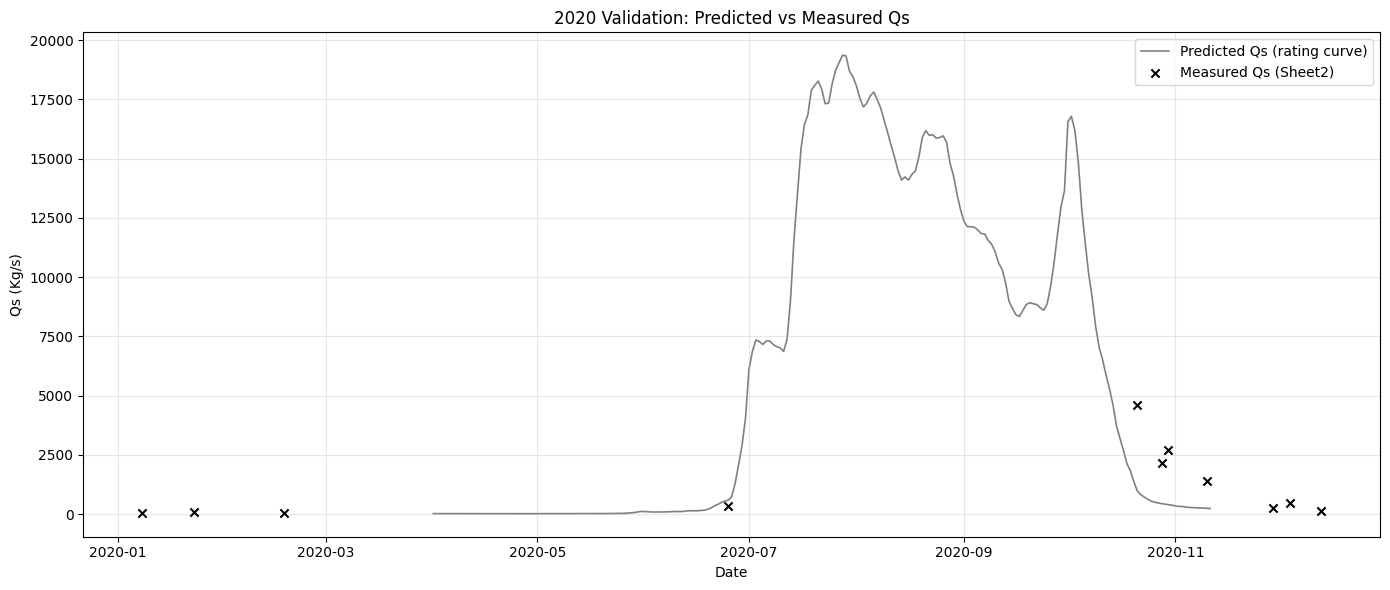

        Date     SSC_Kg/s          Qs    error_%
0 2020-06-25   341.522171  586.277009  71.665871
1 2020-10-21  4582.091969  974.379302 -78.735056
2 2020-10-28  2149.738330  438.523909 -79.601056
3 2020-10-30  2706.201704  396.428287 -85.351118
4 2020-11-10  1375.788841  243.016233 -82.336226
Mean Absolute % Error: 79.54%


In [17]:
# ---------- 11. VALIDATION PLOT FOR 2020 (predicted vs measured) ----------
FILE_SSC = r'G:\Suspended Sediment of Ganges River Remote Sensing\Data_SSC_BWDB.xlsx'
df_meas = pd.read_excel(FILE_SSC, sheet_name='Sheet2')
df_meas['Date'] = pd.to_datetime(df_meas['Date'], errors='coerce')
df_meas = df_meas.dropna(subset=['Date', 'Discharge_m3/s', 'SSC_Kg/s'])
df_meas_2020 = df_meas[df_meas['Date'].dt.year == 2020]

d_pred_2020 = df_daily[df_daily['year'] == 2020]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(d_pred_2020['Date'], d_pred_2020['Qs'], color='gray', linewidth=1.2,
        label='Predicted Qs (rating curve)', zorder=1)
ax.scatter(df_meas_2020['Date'], df_meas_2020['SSC_Kg/s'], color='black', s=35,
           marker='x', label='Measured Qs (Sheet2)', zorder=2)

ax.set_title('2020 Validation: Predicted vs Measured Qs')
ax.set_xlabel('Date')
ax.set_ylabel('Qs (Kg/s)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'validation_2020.png'), dpi=150)
plt.show()

# error stats where dates overlap
merged = pd.merge(df_meas_2020[['Date', 'SSC_Kg/s']], d_pred_2020[['Date', 'Qs']], on='Date', how='inner')
if not merged.empty:
    merged['error_%'] = (merged['Qs'] - merged['SSC_Kg/s']) / merged['SSC_Kg/s'] * 100
    print(merged[['Date', 'SSC_Kg/s', 'Qs', 'error_%']])
    print(f"Mean Absolute % Error: {merged['error_%'].abs().mean():.2f}%")
else:
    print("No overlapping dates between measured and predicted — dates in Sheet2 don't fall on exact daily-resampled dates.")